# Final Model Evaluation

This notebook evaluates our selected candidate model: **Decision Tree Regressor (`max_depth=3`)** on the holdout test set. We analyze predictions, calculate evaluation metrics (MAE, RMSE, R²), and examine prediction residuals to understand the model's systematic errors.



## 1. Load Data and Pipeline

We load the preprocessed dataset, split into features and target, and import the preprocessing ColumnTransformer.



In [1]:
import pandas as pd
import numpy as np
import os
import sys

# Append parent directory to sys.path to allow importing src
sys.path.append(os.path.abspath(".."))

from src.features.preprocessing import build_preprocessor

# Load preprocessed dataset
df = pd.read_csv("../data/processed/mxmh_cleaned.csv")
y = df["Anxiety"]
X = df.drop(columns=["Anxiety", "Depression", "Insomnia", "OCD"])

categorical_cols = list(X.select_dtypes(include=["object", "category"]).columns)
numerical_cols = list(X.select_dtypes(include=["int64", "float64"]).columns)



C:\Users\aksha\AppData\Local\Temp\ipykernel_15924\613361486.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = list(X.select_dtypes(include=["object", "category"]).columns)


In [2]:
from sklearn.model_selection import train_test_split

# Split into 80/20 Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Build pipeline preprocessing transformer
preprocessor = build_preprocessor(numerical_cols, categorical_cols)



## 2. Fit Selected Model and Generate Predictions

We train a `DecisionTreeRegressor` restricted to `max_depth=3` on the training partition and predict on the test partition.



In [3]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor

# Instantiate and fit the model pipeline
model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", DecisionTreeRegressor(max_depth=3, random_state=42))
])

# Fit on training data
model_pipeline.fit(X_train, y_train)

# Predict on test data
y_pred = model_pipeline.predict(X_test)



## 3. Calculate Performance Metrics

We calculate MAE, RMSE, and R² on the test set.



In [4]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Test MAE : {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test R²  : {r2:.4f}")



Test MAE : 2.2603
Test RMSE: 2.7499
Test R²  : 0.0636


## 4. Compare Actual vs Predicted Values

We plot actual anxiety scores against predicted scores to see the prediction spread.



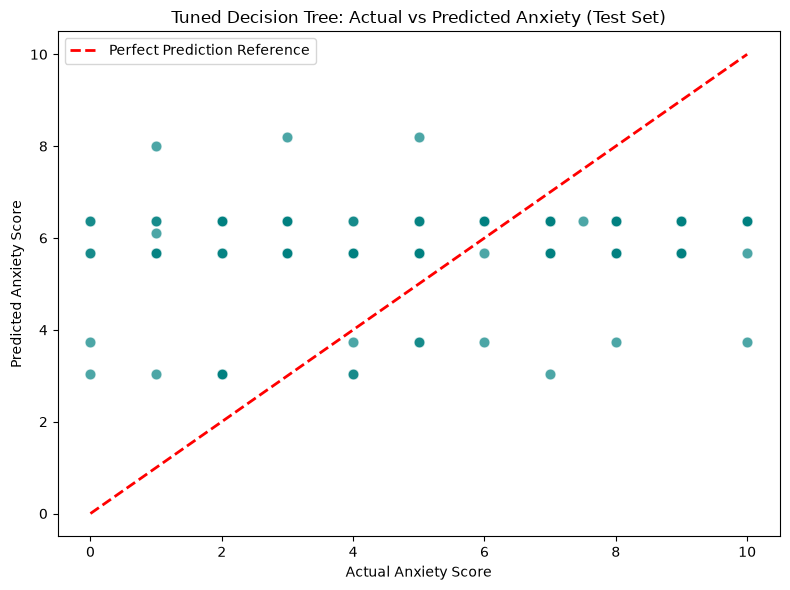

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7, color="teal", edgecolor="w", s=60)
plt.plot([0, 10], [0, 10], "r--", lw=2, label="Perfect Prediction Reference")
plt.title("Tuned Decision Tree: Actual vs Predicted Anxiety (Test Set)")
plt.xlabel("Actual Anxiety Score")
plt.ylabel("Predicted Anxiety Score")
plt.xlim(-0.5, 10.5)
plt.ylim(-0.5, 10.5)
plt.legend()
plt.tight_layout()
plt.savefig("../docs/figures/final_actual_vs_predicted.png", dpi=120)
plt.show()



## 5. Residual Analysis

We compute residuals (Actual - Predicted) and analyze their distribution.



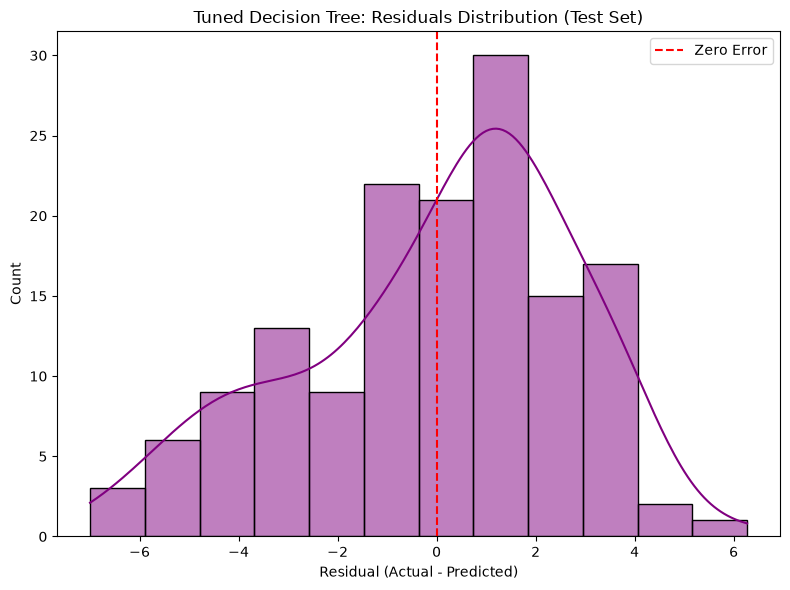

In [6]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True, color="purple", bins=12)
plt.axvline(0, color="red", linestyle="--", linewidth=1.5, label="Zero Error")
plt.title("Tuned Decision Tree: Residuals Distribution (Test Set)")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.savefig("../docs/figures/final_residuals_distribution.png", dpi=120)
plt.show()



### Observations on Systematic Errors:
1. **Prediction Compression**: The model predictions range strictly from `3.03` to `8.20`, whereas the actual anxiety scores range from `0` to `10`.
2. **Under/Overprediction Bias**:
   - The model systematically **overpredicts** low anxiety levels (actual scores 0–2 are predicted as ~3.03 to ~4.5).
   - The model systematically **underpredicts** high anxiety levels (actual scores 8–10 are predicted as ~6.36 to ~8.20).
3. **Reasoning**: This occurs because the depth-limited tree merges observations into a small number of leaf nodes, outputting the average of the targets in those nodes. The averaging process naturally compresses predictions toward the sample mean, smoothing out individual extremes.

